<a href="https://colab.research.google.com/github/yyalexlee/EastAsiaClimateExtremes/blob/main/Weekly_Extreme_Statistics_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**💻Weekly Extreme Analysis: Frequency, Mean, and Max Intensity**

> **Updated** 28-Aug-2026 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will analyze weekly averaged or accumulated climate extremes from ERA5 over East Asia. You will calculate climatological weekly extreme statistics (frequency, mean intensity, max intensity) and visualize them spatially.

NOTE: The codes for calculating extreme statistics were written to handle the limited RAM constraints of Google Colab through use of Dask chunking.

Data Directory: 2.Weekly_ERA5

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Download data**

Create FIRST directories if needed with the following line OR by yourself.

You can change the following path.

In [ ]:
#!mkdir -p /content/drive/MyDrive/APCC/Data/

Refer to the GitHub page for downloading data.

Run the following line to unzip the data OR unzip by yourself.

In [ ]:
#!unzip '/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5.zip' -d '/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/'

✅ Delete the zip files to save space.

## **Import libraries**

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.4 MB/s eta 0:00:00


In [ ]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import dask
from dask.diagnostics import ProgressBar
from pathlib import Path

This is to define the min and max values of colorbar automatically.

In [ ]:
def get_vmin_vmax(data, percentile_min=2, percentile_max=98):
    valid_data = data.values[~np.isnan(data.values)].flatten()
    if len(valid_data) == 0:
        print(f"Warning: No valid data found. Using data min/max instead.")
        vmin = float(np.nanmin(data.values))
        vmax = float(np.nanmax(data.values))
    else:
        vmin = float(np.percentile(valid_data, percentile_min))
        vmax = float(np.percentile(valid_data, percentile_max))
    return vmin, vmax

## **Set paths**

CHANGE the following paths if needed!

In [ ]:
PATH_data = "/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/"
PATH_save_stat = "/content/drive/MyDrive/APCC/statistics/"
PATH_save_fig = "/content/drive/MyDrive/APCC/figures/"

In [ ]:
Path(PATH_save_stat).mkdir(parents=True, exist_ok=True)
Path(PATH_save_fig).mkdir(parents=True, exist_ok=True)

## **Set options**

Percentile threshold for extremes, Climatology reference period, Domain of interest


In [ ]:
boundary = 0.90
ref_syear, ref_eyear = 1991, 2020

lon_min, lon_max = 114, 141
lat_min, lat_max = 21, 48

## **Load pre-computed 7-Day Rolling Averages / Sums and 90th percentile threshold**

***"You CAN change the target variable BELOW."***

In [ ]:
varname = 'HR' # HR, AHT, MHW

In [ ]:
if varname == 'AHT':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_T2m_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    data = ds.t2m_7day
    threshold_file = os.path.join(PATH_data, "T2m_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    data = data - 273.15
    threshold = threshold - 273.15
    unit = 'degC'
    cmap = 'YlOrRd'

elif varname == 'HR':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_TP_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    data = ds.tp_7day
    threshold_file = os.path.join(PATH_data, "TP_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    unit = 'mm'
    cmap = 'YlGnBu'

elif varname == 'MHW':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_SST_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    data = ds.sst_7day
    threshold_file = os.path.join(PATH_data, "SST_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    data = data - 273.15
    threshold = threshold - 273.15
    unit = 'degC'
    cmap = 'YlOrRd'

/tmp/ipykernel_1696/1413325534.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


# Harmonize coordinate names

In [ ]:
rename_dict = {}
if 'latitude' in data.dims:
    rename_dict['latitude'] = 'lat'
if 'longitude' in data.dims:
    rename_dict['longitude'] = 'lon'
if rename_dict:
    data = data.rename(rename_dict)

rename_dict_thr = {}
if 'latitude' in threshold.dims:
    rename_dict_thr['latitude'] = 'lat'
if 'longitude' in threshold.dims:
    rename_dict_thr['longitude'] = 'lon'
if rename_dict_thr:
    threshold = threshold.rename(rename_dict_thr)

# Ensure latitude is sorted consistently for data and threshold

In [ ]:
data = data.sortby('lat')
threshold = threshold.sortby('lat')

# Select weekly representatives: Monday (dayofweek == 0)

In [ ]:
data = data.sel(time=data.time.dt.dayofweek == 0)

In [ ]:
ds

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 31041, lat: 19, lon: 19)
Coordinates:
  * time     (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-25
  * lat      (lat) float64 152B 48.0 46.5 45.0 43.5 42.0 ... 25.5 24.0 22.5 21.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    number   int64 8B ...
    doy      (time) int64 248kB dask.array<chunksize=(180,), meta=np.ndarray>
Data variables:
    tp_7day  (time, lat, lon) float64 90MB dask.array<chunksize=(180, 10, 10), meta=np.ndarray>

In [ ]:
data

<xarray.DataArray 'tp_7day' (time: 4435, lat: 19, lon: 19)> Size: 13MB
dask.array<getitem, shape=(4435, 19, 19), dtype=float64, chunksize=(179, 9, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 35kB 1940-01-01 1940-01-08 ... 2024-12-23
  * lat      (lat) float64 152B 21.0 22.5 24.0 25.5 27.0 ... 43.5 45.0 46.5 48.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    number   int64 8B ...
    doy      (time) int64 35kB dask.array<chunksize=(179,), meta=np.ndarray>
Attributes:
    long_name:  7-day rolling sum of total precipitation
    units:      mm
    window:     7

In [ ]:
threshold

<xarray.DataArray 'clim_90th' (doy: 366, lat: 121, lon: 240)> Size: 85MB
[10628640 values with dtype=float64]
Coordinates:
  * doy      (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365 366
  * lat      (lat) float64 968B -90.0 -88.5 -87.0 -85.5 ... 85.5 87.0 88.5 90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Attributes:
    long_name:         Climatological 90th percentile threshold of weekly sum TP
    units:             mm
    reference_period:  1991-2020
    window_size:       7-days

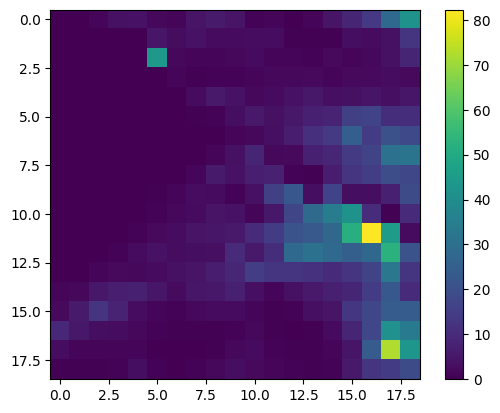

In [ ]:
plt.imshow(data[0,...].values); plt.colorbar()

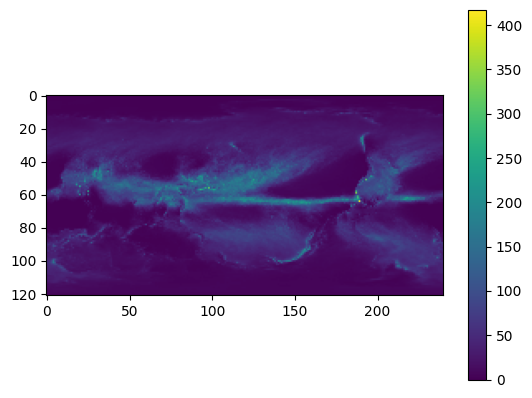

In [ ]:
plt.imshow(threshold[0,...].values); plt.colorbar()

# Select East Asia region to reduce memory footprint

In [ ]:
data_sel = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
threshold_sel = threshold.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

print(f"Data shape after region selection: {data_sel.shape}")
print(f"Threshold shape after region selection: {threshold_sel.shape}")

Data shape after region selection: (4435, 19, 19)
Threshold shape after region selection: (366, 19, 19)


In [ ]:
print(data_sel.shape)

(4435, 19, 19)


In [ ]:
print(threshold_sel.shape)

(366, 19, 19)


In [ ]:
data_sel

<xarray.DataArray 'tp_7day' (time: 4435, lat: 19, lon: 19)> Size: 13MB
dask.array<getitem, shape=(4435, 19, 19), dtype=float64, chunksize=(179, 9, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 35kB 1940-01-01 1940-01-08 ... 2024-12-23
  * lat      (lat) float64 152B 21.0 22.5 24.0 25.5 27.0 ... 43.5 45.0 46.5 48.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    number   int64 8B ...
    doy      (time) int64 35kB dask.array<chunksize=(179,), meta=np.ndarray>
Attributes:
    long_name:  7-day rolling sum of total precipitation
    units:      mm
    window:     7

In [ ]:
threshold_sel

<xarray.DataArray 'clim_90th' (doy: 366, lat: 19, lon: 19)> Size: 1MB
[132126 values with dtype=float64]
Coordinates:
  * doy      (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365 366
  * lat      (lat) float64 152B 21.0 22.5 24.0 25.5 27.0 ... 43.5 45.0 46.5 48.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
Attributes:
    long_name:         Climatological 90th percentile threshold of weekly sum TP
    units:             mm
    reference_period:  1991-2020
    window_size:       7-days

## **Calculate Extreme Statistics**

#### **1) Extreme Frequency per Year**

Frequency [times/yr]

Identify weeks exceeding the threshold and count extreme weeks by year.

#### **2) Mean Intensity of Extreme Weeks**

Intensity [unit/yr]

Calculate mean intensity on weeks flagged as extreme and then sum by year.

#### **3) Mean Maximum Intensity of Extreme Weeks (mm/yr)**

Max Intensity [unit/yr]

**First computing extreme mask.**

# Expand threshold to match time dimension via day-of-year

In [ ]:
doy = data_sel['time.dayofyear']
threshold_expanded = threshold_sel.sel(doy=doy)

# Identify extreme weeks (value >= percentile threshold)

In [ ]:
extreme_mask = data_sel >= threshold_expanded


# Compute annual statistics

In [ ]:
print("Computing annual frequency of extreme weeks...")
extreme_counts = extreme_mask.groupby('time.year').sum(dim='time')

print("Computing annual mean intensity of extreme weeks...")
extreme_vals = data_sel.where(extreme_mask)
extreme_mean_intensity = extreme_vals.groupby('time.year').mean(dim='time')

print("Computing annual maximum intensity of extreme weeks...")
extreme_max_intensity = extreme_vals.groupby('time.year').max(dim='time')

with ProgressBar():
    frequency_clim = extreme_counts.mean(dim='year').compute()
    mean_intensity_clim = extreme_mean_intensity.mean(dim='year').compute()
    mean_max_intensity_clim = extreme_max_intensity.mean(dim='year').compute()

Computing annual frequency of extreme weeks...
Computing annual mean intensity of extreme weeks...
Computing annual maximum intensity of extreme weeks...
[########################################] | 100% Completed | 61.22 s
[########################################] | 100% Completed | 53.69 s
[########################################] | 100% Completed | 54.40 s


# For MHW, restrict statistics to ocean grid cells only

In [ ]:
if varname == 'MHW':
    land_mask = data_sel.isnull().all(dim='time')
    frequency_clim = frequency_clim.where(~land_mask)
    mean_intensity_clim = mean_intensity_clim.where(~land_mask)
    mean_max_intensity_clim = mean_max_intensity_clim.where(~land_mask)

# Determine colorbar ranges based on robust percentiles

In [ ]:
freq_vmin, freq_vmax = get_vmin_vmax(frequency_clim, 2, 98)
intensity_vmin, intensity_vmax = get_vmin_vmax(mean_intensity_clim, 2, 98)
max_intensity_vmin, max_intensity_vmax = get_vmin_vmax(mean_max_intensity_clim, 2, 98)

# Prepare plotting configuration: frequency, mean intensity, mean of annual max intensity

In [ ]:
plot_info = [
    (frequency_clim, "Frequency [times/year]", freq_vmin, freq_vmax, cmap),
    (mean_intensity_clim, f"Mean Intensity [{unit}]", intensity_vmin, intensity_vmax, cmap),
    (mean_max_intensity_clim, f"Mean of Annual Max Intensity [{unit}]", max_intensity_vmin, max_intensity_vmax, cmap),
]

## **Display individual plots**

# Create three-panel map plot over East Asia

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


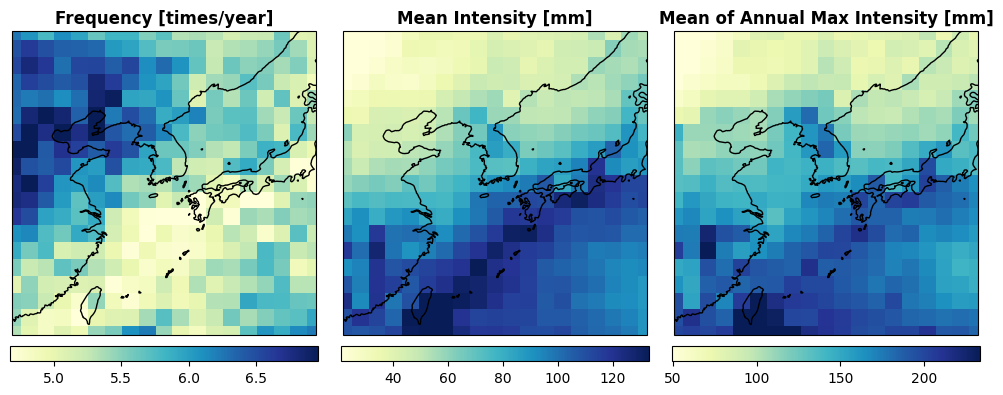

Saved figure to: /content/drive/MyDrive/APCC/figures/weeklyHR_stats_maps__1940-2024__p90.png


In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(10, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, (data_plot, title, vmin, vmax, cmap_) in zip(axes, plot_info):
    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12, fontweight="bold")
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.03)

plt.tight_layout()
fig_path = os.path.join(PATH_save_fig, f"weekly{varname}_stats_maps__1940-2024__p{int(boundary*100)}.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"Saved figure to: {fig_path}")

## **Combined Visualization & Save Figure**

# Assemble and save statistics as a NetCDF dataset

In [ ]:
ds_extremes = xr.Dataset(
    {
        "frequency": frequency_clim,
        "mean_intensity": mean_intensity_clim,
        "mean_of_annual_max_intensity": mean_max_intensity_clim,
    }
)
# Add basic metadata
ds_extremes.frequency.attrs["units"] = "times/year"
ds_extremes.mean_intensity.attrs["units"] = unit
ds_extremes.mean_of_annual_max_intensity.attrs["units"] = unit
ds_extremes.attrs["reference_period_for_threshold"] = f"{ref_syear}-{ref_eyear}"
ds_extremes.attrs["statistical_period"] = "all available years in selected dataset"
ds_extremes.attrs["description"] = f"Climatological weekly extreme statistics for {varname} over East Asia"

out_path = os.path.join(
    PATH_save_stat,
    f"weekly{varname}_stats_maps__1940-2024__p{int(boundary*100)}.nc"
)
ds_extremes.to_netcdf(out_path)

print(f"Saved NetCDF to: {out_path}")

Saved NetCDF to: /content/drive/MyDrive/APCC/statistics/weeklyHR_stats_maps__1940-2024__p90.nc
